In [3]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

In [4]:
import os
path=r"C:\Users\poula\Downloads\archive (2)\brain_tumor_dataset"
print(os.listdir(path))

['no', 'yes']


In [5]:
import cv2
import numpy as np

data = []
labels = []

path = r"C:\Users\poula\Downloads\archive (2)\brain_tumor_dataset"

categories = ["yes", "no"]

for category in categories:
    folder_path = os.path.join(path, category)
    label = 1 if category == "yes" else 0
    
    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)
        
        try:
            img = cv2.imread(img_path)
            img = cv2.resize(img, (128, 128))
            
            data.append(img)
            labels.append(label)
        except:
            pass  # skip broken images

data = np.array(data) / 255.0
labels = np.array(labels)

print("Data loaded successfully")
print("Total images:", len(data))

Data loaded successfully
Total images: 253


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.2, random_state=42
)

# One-hot encoding
y_train = to_categorical(y_train, 2)
y_test = to_categorical(y_test, 2)

In [7]:
model = Sequential()

# 1st Layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))

# 2nd Layer
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# 3rd Layer
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Flatten
model.add(Flatten())

# Fully Connected
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(2, activation='softmax'))

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

C:\Users\poula\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,898 (12.61 MB)

 Trainable params: 3,304,898 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_test, y_test),
    batch_size=32
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 386ms/step - accuracy: 0.6337 - loss: 0.7587 - val_accuracy: 0.6471 - val_loss: 0.6152
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 313ms/step - accuracy: 0.7574 - loss: 0.5689 - val_accuracy: 0.7255 - val_loss: 0.5609
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 304ms/step - accuracy: 0.8020 - loss: 0.4973 - val_accuracy: 0.7059 - val_loss: 0.5434
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 271ms/step - accuracy: 0.7970 - loss: 0.4767 - val_accuracy: 0.8039 - val_loss: 0.5193
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 267ms/step - accuracy: 0.8069 - loss: 0.4382 - val_accuracy: 0.7843 - val_loss: 0.5197
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 278ms/step - accuracy: 0.7921 - loss: 0.4296 - val_accuracy: 0.8039 - val_loss: 0.5000
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 284ms/step - accuracy: 0.8366 - loss: 0.3750 - val_accuracy: 0.8235 - val_loss: 0.4649
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 271ms/step - accuracy: 0.8713 - loss: 0.3355 - val_accuracy: 0.7647 - val_loss:

In [9]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.7059 - loss: 0.5238
Test Accuracy: 0.7058823704719543


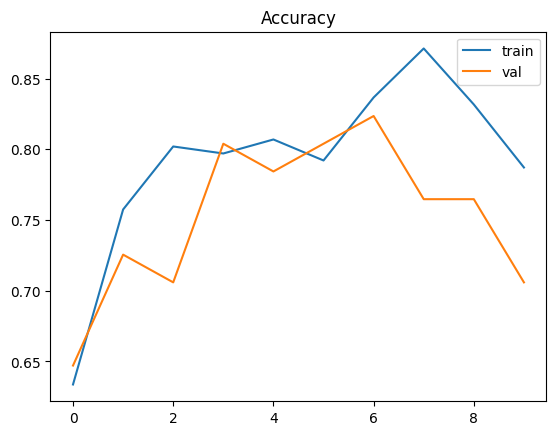

In [10]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("Accuracy")
plt.legend()
plt.show()

In [11]:
def predict_image(path):
    img = cv2.imread(path)
    
    if img is None:
        print("Error: Image not found or path is wrong!")
        return
    
    img = cv2.resize(img, (128,128))
    img = img / 255.0
    img = np.reshape(img, (1,128,128,3))

    result = model.predict(img)

    if np.argmax(result) == 1:
        print("Tumor Detected")
    else:
        print("No Tumor")

In [12]:
import os
print(os.path.exists("test.jpg"))

False


In [13]:
model.save('brain_tumor_model.h5')

In [14]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model

# 1. Load your saved model
model = load_model('brain_tumor_model.h5')

# 2. Define the input shape (based on your training: 128x128 with 3 color channels)
# Use a batch size of 1
input_shape = (1, 128, 128, 3)

# 3. Create dummy data (a bunch of zeros)
dummy_data = np.zeros(input_shape).astype('float32')

# 4. THE FIX: "Call" the model on this dummy data
# This connects the layers and initializes the symbolic outputs
_ = model(dummy_data)

print("Model has been called. Sequential layers are now initialized!")

Model has been called. Sequential layers are now initialized!
